In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [11]:
df = pd.read_csv('heart_disease_dataset.csv')

print(f"Dimensi Dataset Awal: {df.shape[0]} baris, {df.shape[1]} kolom\n")
display(df.head())

df.info()

print("\nStatistik Deskriptif")
display(df.describe().T)

Dimensi Dataset Awal: 1025 baris, 14 kolom



,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Statistik Deskriptif


,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [ ]:
column_mapping = {
    'age': 'Age',
    'sex': 'Sex',
    'cp': 'ChestPainType',
    'trestbps': 'RestingBP',
    'chol': 'Cholesterol',
    'fbs': 'FastingBS',
    'restecg': 'RestingECG',
    'thalach': 'MaxHR',
    'exang': 'ExerciseAngina',
    'oldpeak': 'Oldpeak',
    'slope': 'ST_Slope',
    'ca': 'MajorVessels',
    'thal': 'Thalassemia',
    'target': 'HeartDisease'
}

df_clean = df.rename(columns=column_mapping)
display(df_clean.head(3))

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,MajorVessels,Thalassemia,HeartDisease
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0


In [ ]:
print(f"Jumlah Missing Value Total : {df_clean.isnull().sum().sum()}")
print(f"Jumlah Baris Duplikat Awal : {df_clean.duplicated().sum()}")

df_dedup = df_clean.drop_duplicates().reset_index(drop=True)
print(f"Dimensi Data Setelah Deduplikasi: {df_dedup.shape[0]} baris, {df_dedup.shape[1]} kolom")

Jumlah Missing Value Total : 0
Jumlah Baris Duplikat Awal : 723
Dimensi Data Setelah Deduplikasi: 302 baris, 14 kolom


In [ ]:
num_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

print("IQR")
for col in num_features:
    Q1 = df_dedup[col].quantile(0.25)
    Q3 = df_dedup[col].quantile(0.75)
    IQR = Q3 - Q1 
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_dedup[(df_dedup[col] < lower_bound) | (df_dedup[col] > upper_bound)]
    print(f"Fitur '{col}': {len(outliers)} outlier terdeteksi | Rentang Normal: [{lower_bound:.2f}, {upper_bound:.2f}]")

--- Analisis Outlier Menggunakan Metode IQR ---
Fitur 'Age': 0 outlier terdeteksi | Rentang Normal: [28.50, 80.50]
Fitur 'RestingBP': 9 outlier terdeteksi | Rentang Normal: [90.00, 170.00]
Fitur 'Cholesterol': 5 outlier terdeteksi | Rentang Normal: [115.38, 370.38]
Fitur 'MaxHR': 1 outlier terdeteksi | Rentang Normal: [84.12, 215.12]
Fitur 'Oldpeak': 5 outlier terdeteksi | Rentang Normal: [-2.40, 4.00]


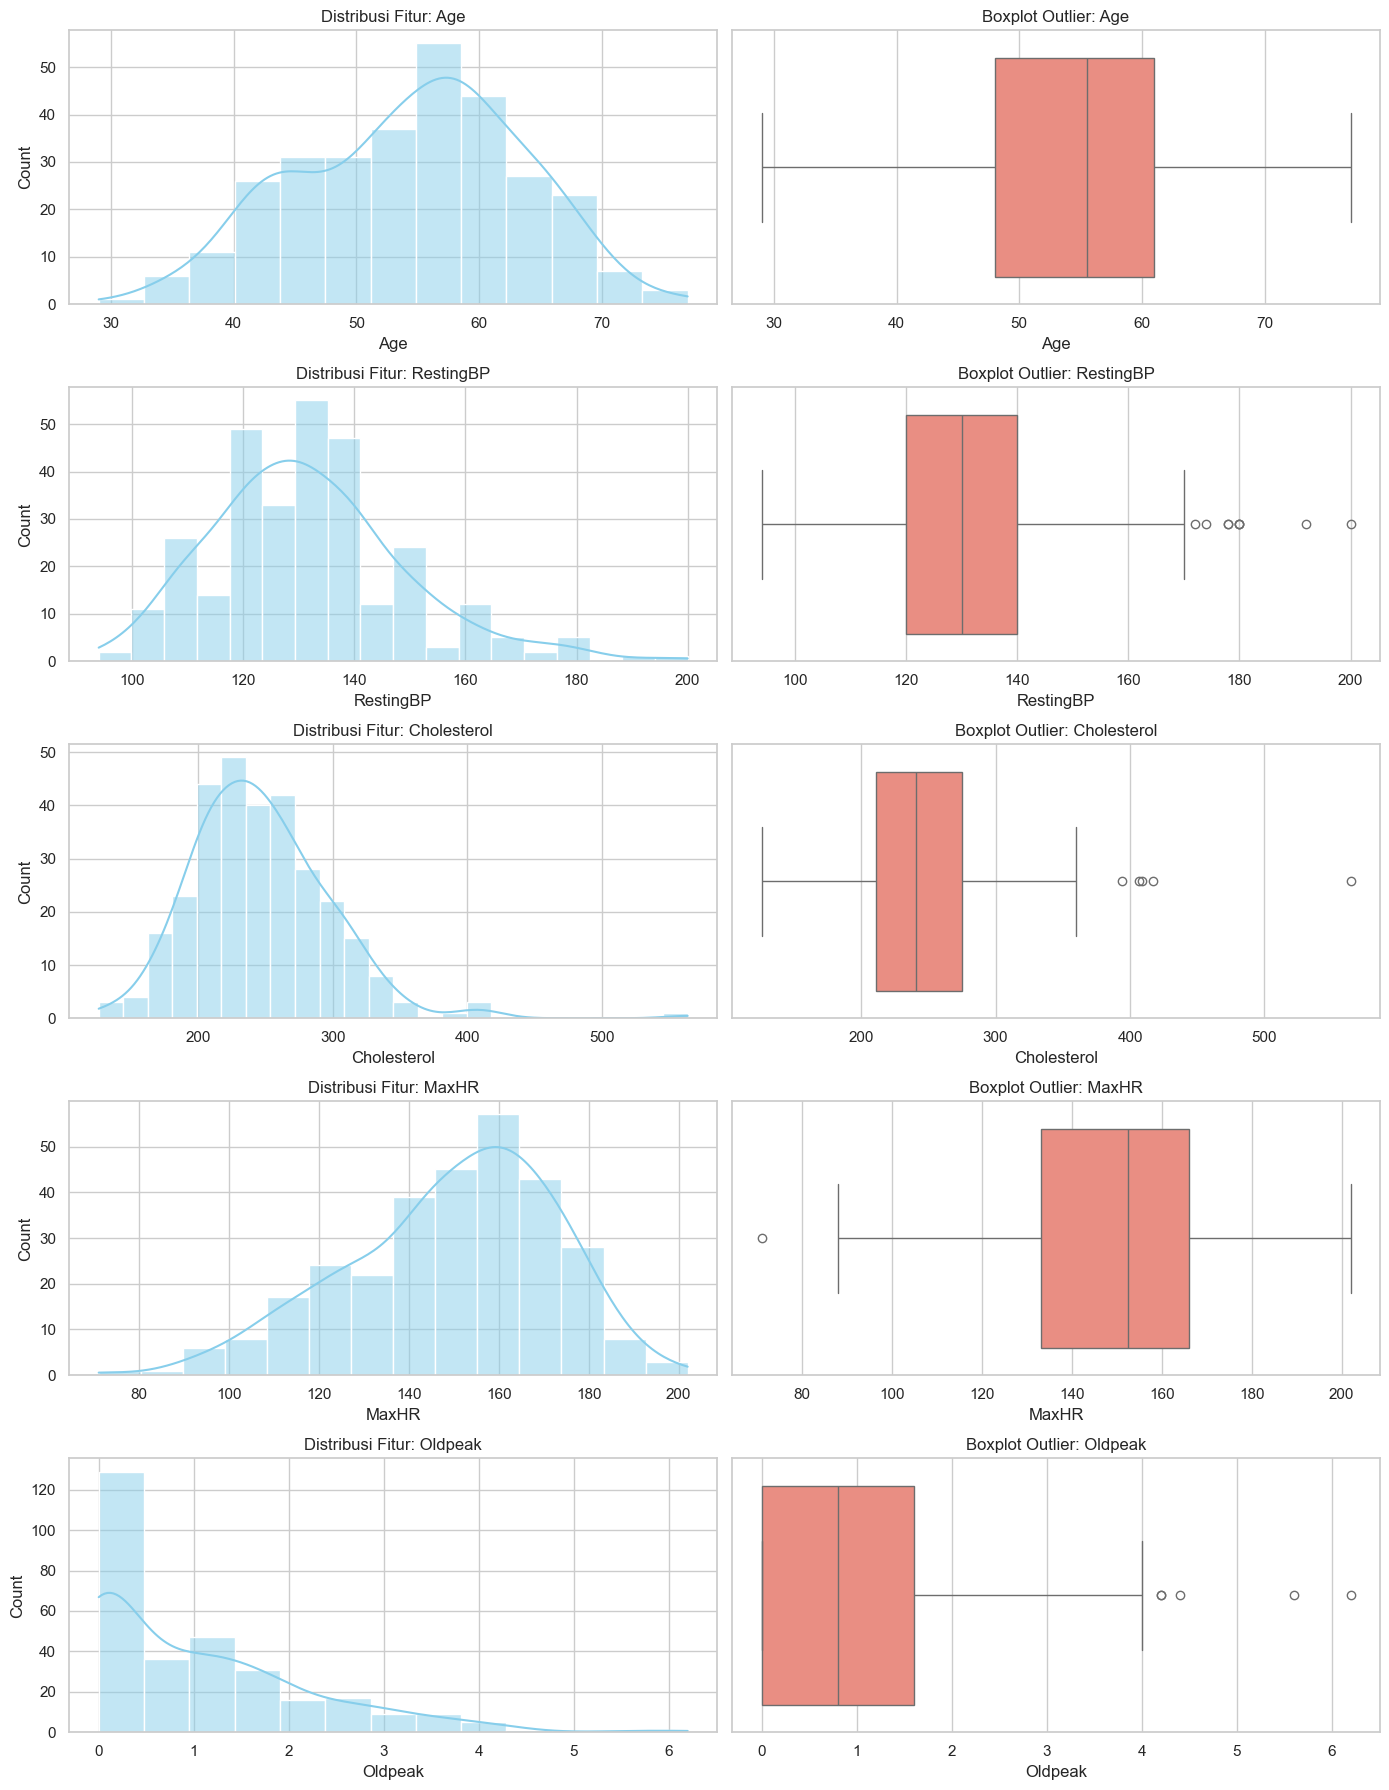

In [15]:
fig, axes = plt.subplots(len(num_features), 2, figsize=(14, 18))

for i, col in enumerate(num_features):
    # Histogram + KDE
    sns.histplot(ax=axes[i, 0], data=df_dedup, x=col, kde=True, color='skyblue')
    axes[i, 0].set_title(f'Distribusi Fitur: {col}')
    
    # Boxplot
    sns.boxplot(ax=axes[i, 1], data=df_dedup, x=col, color='salmon')
    axes[i, 1].set_title(f'Boxplot Outlier: {col}')

plt.tight_layout()
plt.show()

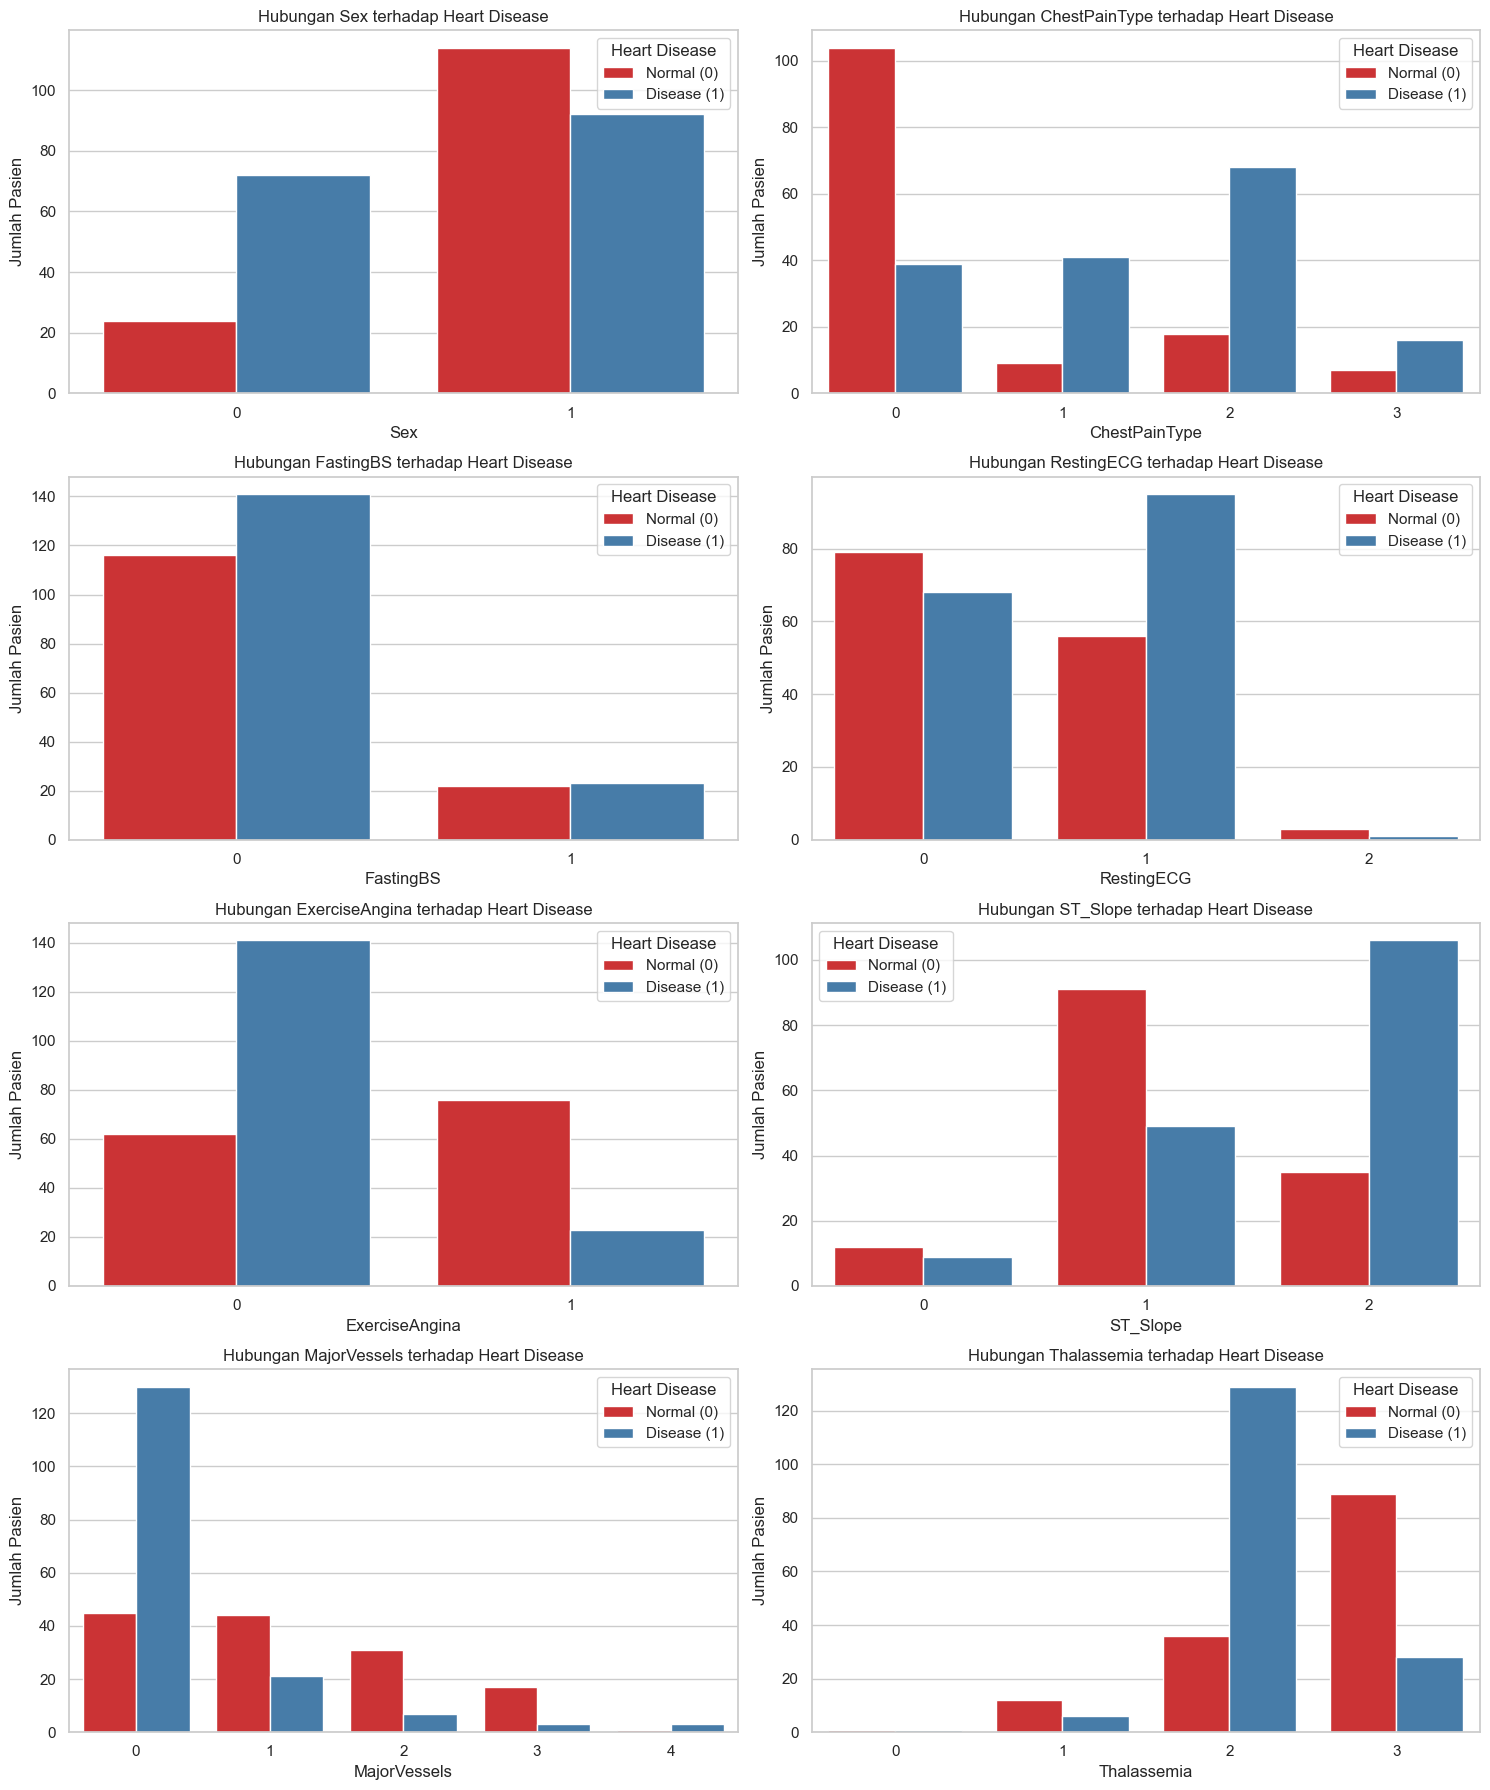

In [16]:
cat_features = ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'MajorVessels', 'Thalassemia']

fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(ax=axes[i], data=df_dedup, x=col, hue='HeartDisease', palette='Set1')
    axes[i].set_title(f'Hubungan {col} terhadap Heart Disease')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah Pasien')
    axes[i].legend(title='Heart Disease', labels=['Normal (0)', 'Disease (1)'])

plt.tight_layout()
plt.show()

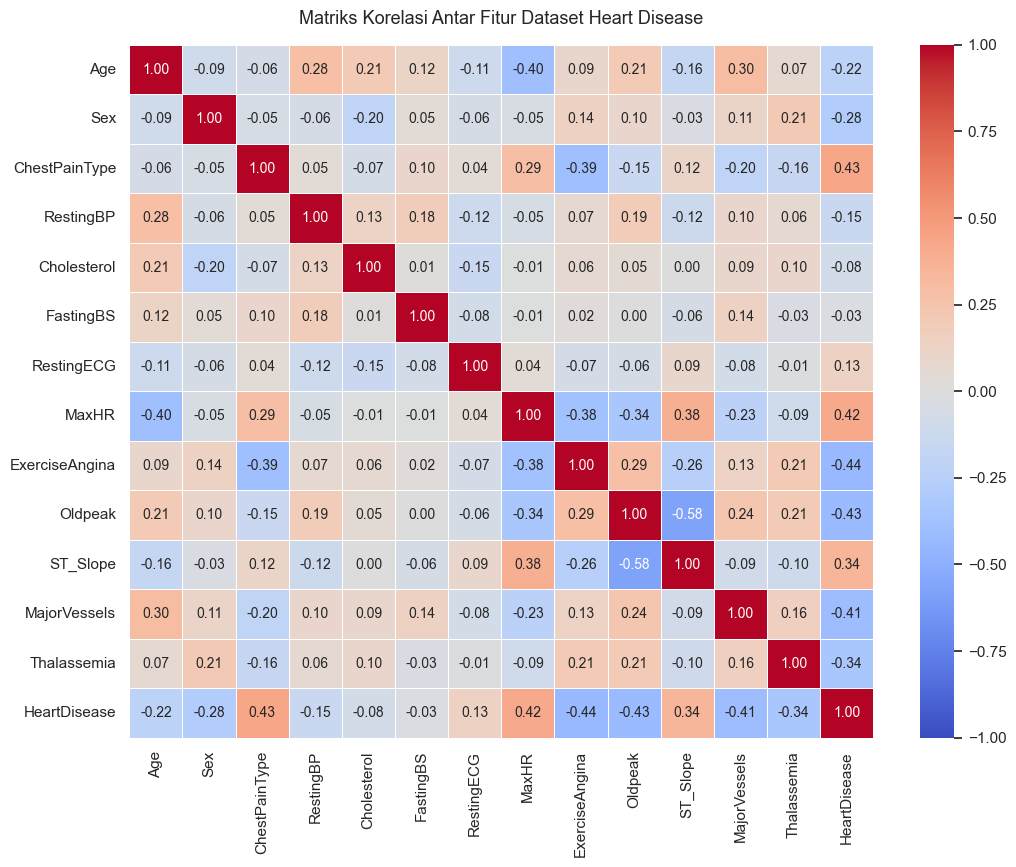

In [17]:
plt.figure(figsize=(12, 9))
corr = df_dedup.corr()

sns.heatmap(
    corr, 
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm', 
    vmin=-1, vmax=1, 
    linewidths=0.5
)

plt.title('Matriks Korelasi Antar Fitur Dataset Heart Disease', fontsize=13, pad=15)
plt.show()